<a href="https://colab.research.google.com/github/Dandyeriametor/Activity/blob/main/Assignment_5_Exploratory_Data_Analysis_with_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Import all the required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from pandas.plotting import scatter_matrix

# Display options (optional)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


Task 1: Load the Dataset

In [4]:
df = pd.read_csv('Titanic-Dataset.csv')
print("Loaded shape:", df.shape)
df.head()

Loaded shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Task 2: Inspect the Data

In [9]:

display(df.head())
display(df.tail())
display(df.dtypes.to_frame("dtype"))
display(df.describe(include="all"))


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


Task 3: Cleaning & Preprocessing

In [10]:
# Harmonize column name access for flexible datasets
df_cols_lower = {c.lower(): c for c in df.columns}
def col(name):
    return df_cols_lower.get(name.lower())

col_Survived = col("Survived")
col_Pclass   = col("Pclass")
col_Sex      = col("Sex")
col_Age      = col("Age")
col_SibSp    = col("SibSp")
col_Parch    = col("Parch")
col_Fare     = col("Fare")
col_Cabin    = col("Cabin")

# 3.1 Pclass categorical
if col_Pclass:
    pclass_map = {1:"First", 2:"Second", 3:"Third"}
    df["Pclass_cat"] = df[col_Pclass].map(pclass_map).astype("category")
else:
    df["Pclass_cat"] = pd.Categorical([])

# 3.2 HasCabin indicator
if col_Cabin:
    df["HasCabin"] = df[col_Cabin].notna().astype(int).astype("category")
else:
    df["HasCabin"] = pd.Categorical([])

# 3.3 Handle missing Age with median within Sex x Pclass
if col_Age:
    if col_Sex and col_Pclass:
        group_medians = df.groupby([col_Sex, col_Pclass])[col_Age].median()
        def fill_age(row):
            if pd.isna(row[col_Age]):
                key = (row[col_Sex], row[col_Pclass])
                if key in group_medians.index:
                    return group_medians.loc[key]
                return df[col_Age].median()
            return row[col_Age]
        df["Age_imputed"] = df.apply(fill_age, axis=1)
    else:
        df["Age_imputed"] = df[col_Age].fillna(df[col_Age].median())
else:
    df["Age_imputed"] = np.nan

# 3.4 Family feature
if col_SibSp and col_Parch:
    df["FamilySize"] = df[col_SibSp].fillna(0) + df[col_Parch].fillna(0) + 1
else:
    df["FamilySize"] = np.nan

df[["Pclass_cat","HasCabin","Age_imputed","FamilySize"]].head(10)

,Pclass_cat,HasCabin,Age_imputed,FamilySize
0,Third,0,22.0,2
1,First,1,38.0,2
2,Third,0,26.0,1
3,First,1,35.0,2
4,Third,0,35.0,1
5,Third,0,25.0,1
6,First,1,54.0,1
7,Third,0,2.0,5
8,Third,0,27.0,3
9,Second,0,14.0,2


Task 4: Identify Specific Data Points

In [11]:

# 4.1 Passengers with the highest fare
if col_Fare:
    max_fare = df[col_Fare].max()
    top_fare_df = df[df[col_Fare] == max_fare]
    print("Highest fare:", max_fare)
    display(top_fare_df)

# 4.2 Passengers with largest family size
if "FamilySize" in df.columns:
    max_family = df["FamilySize"].max()
    top_family_df = df[df["FamilySize"] == max_family]
    print("Largest family size:", max_family)
    display(top_family_df)


Highest fare: 512.3292


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_cat,HasCabin,Age_imputed,FamilySize
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,First,0,35.0,1
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,First,1,36.0,2
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,First,1,35.0,1


Largest family size: 11


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_cat,HasCabin,Age_imputed,FamilySize
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S,Third,0,25.0,11
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S,Third,0,21.5,11
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S,Third,0,25.0,11
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S,Third,0,25.0,11
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S,Third,0,21.5,11
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S,Third,0,25.0,11
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S,Third,0,21.5,11


Task 5: Pandas Series & DataFrame Operations

In [12]:

# Demo Series & DataFrame
demo_series = pd.Series([10, 20, 30, 40], index=["a","b","c","d"], name="demo")
demo_df = pd.DataFrame({"A":[1,2,3,4], "B":[10,20,30,40]}, index=["r1","r2","r3","r4"])

# Indexing / slicing
series_slice = demo_series.loc["b":"d"]
df_slice_rows = demo_df.iloc[1:3]
df_slice_cols = demo_df[["A"]]
df_boolean = demo_df[demo_df["B"] > 15]

display(demo_series.to_frame())
display(demo_df)
display(series_slice.to_frame())
display(df_slice_rows)
display(df_slice_cols)
display(df_boolean)


,demo
a,10
b,20
c,30
d,40


,A,B
r1,1,10
r2,2,20
r3,3,30
r4,4,40


,demo
b,20
c,30
d,40


,A,B
r2,2,20
r3,3,30


,A
r1,1
r2,2
r3,3
r4,4


,A,B
r2,2,20
r3,3,30
r4,4,40


Task 6: Multi-index Survival Rates by Sex & Pclass

In [13]:

if col_Survived and col_Sex and col_Pclass:
    survival_table = (df.groupby([df[col_Sex], df[col_Pclass]])[col_Survived]
                        .mean().rename("SurvivalRate").to_frame())
    survival_table.index.set_names(["Sex","Pclass"], inplace=True)
    display(survival_table)
else:
    survival_table = pd.DataFrame()


SurvivalRate
Sex    Pclass              
female 1           0.968085
       2           0.921053
       3           0.500000
male   1           0.368852
       2           0.157407
       3           0.135447

Task 7: Visualizations

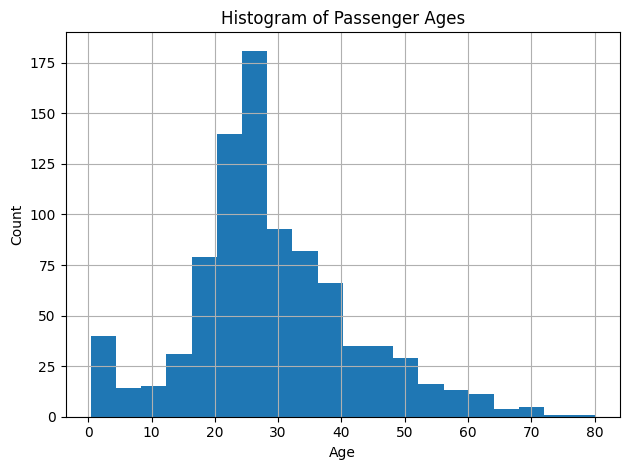

In [14]:

# 7a) Histogram of passenger ages (imputed)
if "Age_imputed" in df.columns and df["Age_imputed"].notna().any():
    plt.figure()
    df["Age_imputed"].dropna().hist(bins=20)
    plt.title("Histogram of Passenger Ages")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


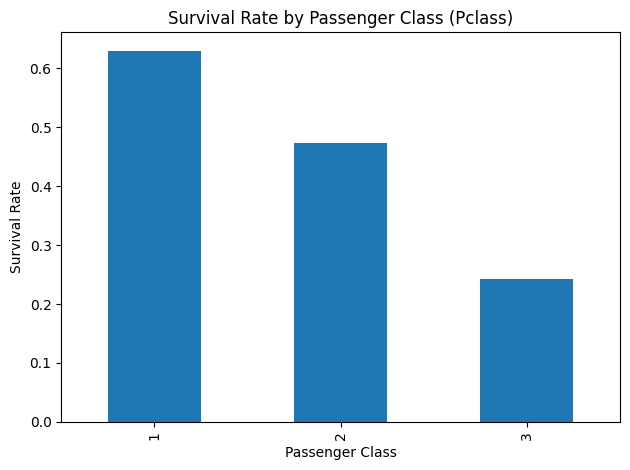

In [15]:

# 7b) Bar plot of survival rates by passenger class
if col_Survived and col_Pclass:
    plt.figure()
    (df.groupby(df[col_Pclass])[col_Survived].mean()
       .sort_index()
       .plot(kind="bar"))
    plt.title("Survival Rate by Passenger Class (Pclass)")
    plt.xlabel("Passenger Class")
    plt.ylabel("Survival Rate")
    plt.tight_layout()
    plt.show()


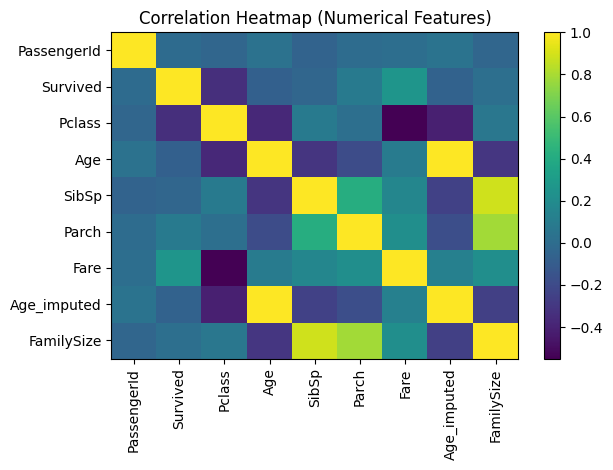

In [16]:

# 7c) Correlation heatmap (numerical features)
num_df = df.select_dtypes(include=[np.number]).copy()
if not num_df.empty:
    corr = num_df.corr(numeric_only=True)
    plt.figure()
    plt.imshow(corr.values, aspect="auto", interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Heatmap (Numerical Features)")
    plt.tight_layout()
    plt.show()


<Figure size 640x480 with 0 Axes>

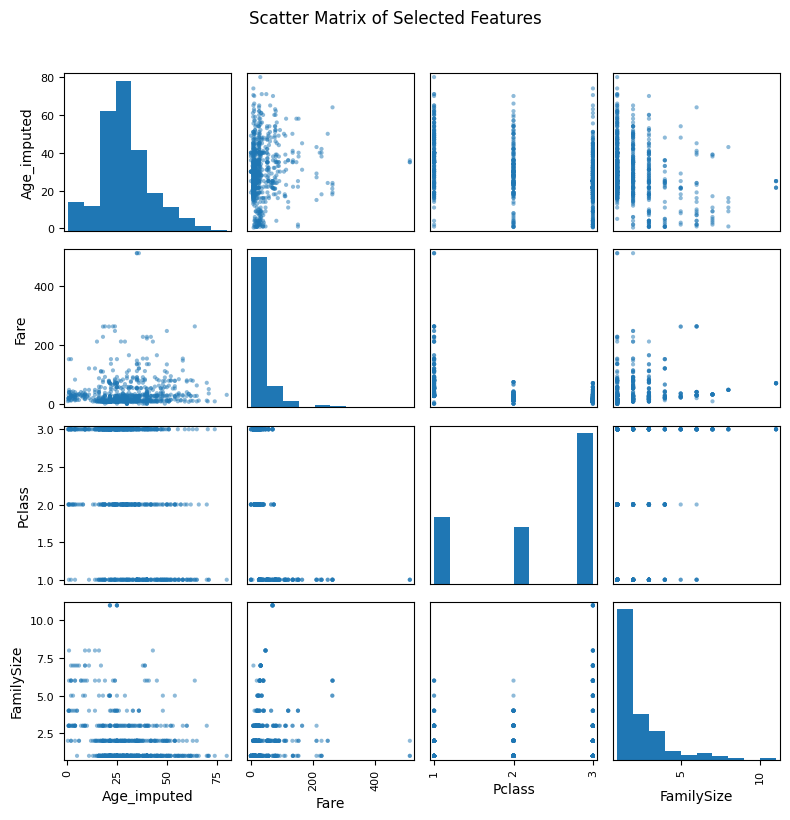

In [17]:

# 7d) Pair plot (scatter-matrix) of selected features
selected_cols = []
for c in ["Age_imputed", col_Fare, col_Pclass, "FamilySize"]:
    if isinstance(c, str) and c in df.columns:
        selected_cols.append(c)
    elif c is not None and c in df.columns:
        selected_cols.append(c)

if len(selected_cols) >= 2:
    plt.figure()
    scatter_matrix(df[selected_cols].dropna(), figsize=(8,8), diagonal="hist")
    plt.suptitle("Scatter Matrix of Selected Features", y=1.02)
    plt.tight_layout()
    plt.show()


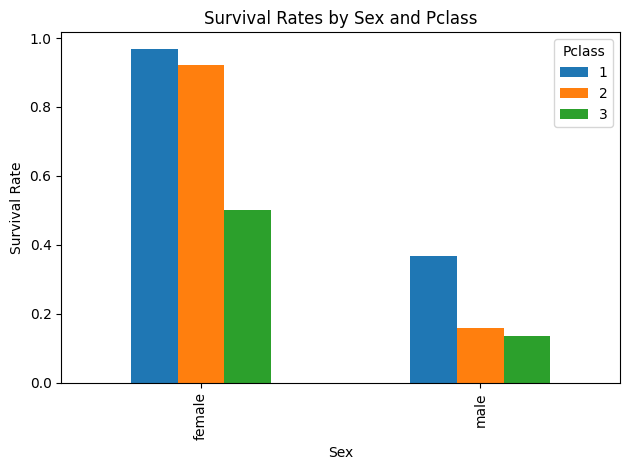

In [18]:

# 7e) Survival rates by Sex and Pclass (grouped bar)
if col_Survived and col_Sex and col_Pclass:
    rates = df.groupby([df[col_Sex], df[col_Pclass]])[col_Survived].mean().unstack()
    rates.plot(kind="bar")
    plt.title("Survival Rates by Sex and Pclass")
    plt.xlabel("Sex")
    plt.ylabel("Survival Rate")
    plt.legend(title="Pclass")
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-3781712752.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df["Age_imputed"].dropna().values, vert=True, labels=["Age"])


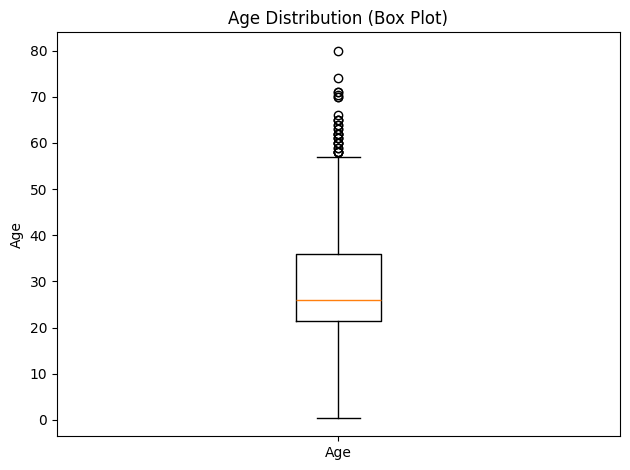

In [19]:

# 7f) Age distribution (box plot)
if "Age_imputed" in df.columns and df["Age_imputed"].notna().any():
    plt.figure()
    plt.boxplot(df["Age_imputed"].dropna().values, vert=True, labels=["Age"])
    plt.title("Age Distribution (Box Plot)")
    plt.ylabel("Age")
    plt.tight_layout()
    plt.show()


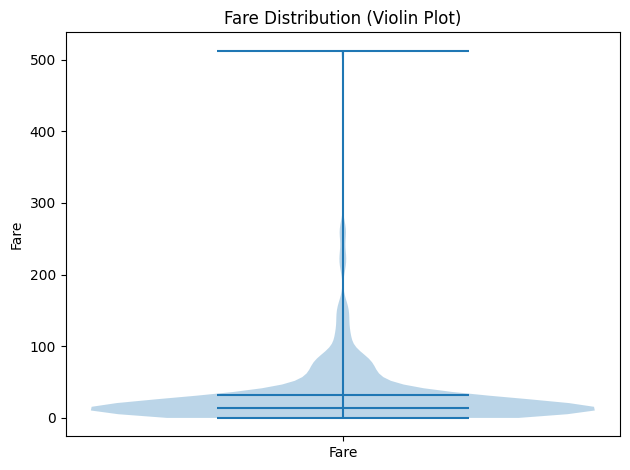

In [20]:

# 7g) Fare distribution (violin plot)
if col_Fare and df[col_Fare].notna().any():
    plt.figure()
    plt.violinplot(df[col_Fare].dropna().values, showmeans=True, showmedians=True)
    plt.title("Fare Distribution (Violin Plot)")
    plt.ylabel("Fare")
    plt.xticks([1], ["Fare"])
    plt.tight_layout()
    plt.show()


8. Markdown Notes — EDA Insights



*  Age Imputation: Missing ages were filled using the median within Sex × Pclass groups to preserve demographic structure. List item
*   Family Groups: FamilySize = SibSp + Parch + 1. Large family clusters are rare; family size can interact with survival outcomes.List item


*   Class Effects: Survival generally trends First > Second > Third; within each class, female survival rates are typically higher.List item
*   Correlations: Expect Fare to correlate with Pclass and weakly with other numeric features. Inspect the heatmap for exact values.List item


*   Distributions: Age shows multiple modes (children/adults); Fare is highly right-skewed with large outliers visible in the violin plot.List item




